# US Equity Portfolio - Risk & Return Analysis

## Notebook Overview

This notebook evaluates asset-level and portfolio-level risk and return characteristics for
the project's five equity holdings:

- **NVDA** - NVIDIA Corporation
- **JPM** - JPMorgan Chase & Co.
- **AMZN** - Amazon.com, Inc.
- **LLY** - Eli Lilly and Company
- **XOM** - Exxon Mobil Corporation

Portfolio performance is measured against the **S&P 500** (`^GSPC`) as the benchmark.

It builds on the data already inspected in `01_data_exploration.ipynb` and covers: individual
asset risk/return metrics, the fixed-weight portfolio construction, portfolio-level metrics,
a portfolio-vs-benchmark comparison, a risk/return scatter, historical portfolio drawdown, and
each asset's contribution to total portfolio risk. All calculations reuse the project's approved
`src.metrics` and `src.portfolio` functions; nothing here reimplements a financial formula.

## Imports and Configuration

Only the packages needed for this notebook are imported below. Project constants (tickers,
benchmark, portfolio weights) and the price-loading, metrics, and portfolio functions are
imported directly from `config` and the approved `src` package rather than being redefined here.
`src.visualizations` is intentionally not imported: it forces the non-interactive `Agg` backend
and always saves chart files to disk, which is unnecessary and undesirable for an inline,
notebook-native exploration like this one.

The cell below locates the project root by walking upward from the current working directory
until it finds `config.py`, and adds it to `sys.path`. This makes the notebook work whether
Jupyter's working directory is the repository root or the `notebooks/` folder itself.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Locate the project root (the directory containing config.py) by walking upward."""
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "config.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root (config.py not found).")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\andhr\Downloads\us-equity-portfolio-analytics\us-equity-portfolio-analytics


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Markdown, display

from config import BENCHMARK, PORTFOLIO_WEIGHTS, TICKERS
from src import data_loader, metrics, portfolio

sns.set_theme(style="whitegrid")
%matplotlib inline

The helper below performs percentage/decimal formatting for display purposes only - it does
not alter, recompute, or approximate any financial metric. All underlying values still come
directly from the approved `src.metrics` / `src.portfolio` functions.

In [3]:
def _format_metrics_table(table: pd.DataFrame) -> pd.DataFrame:
    """Return a percentage/2-decimal formatted COPY of a metrics table, for display only."""
    formatted = table.copy()
    for column in ("Annualized Return", "Annualized Volatility", "Max Drawdown"):
        if column in formatted.columns:
            formatted[column] = formatted[column].map(lambda v: f"{v:.1%}")
    for column in ("Sharpe Ratio", "Beta"):
        if column in formatted.columns:
            formatted[column] = formatted[column].map(lambda v: f"{v:.2f}")
    return formatted

## Load Cached Data

Prices are loaded using the approved `load_price_data()` function, and daily returns are
calculated using the approved `calculate_daily_returns()` function. Both simply read the
already-validated cache and compute returns - neither downloads any data.

In [4]:
prices = data_loader.load_price_data()
returns = metrics.calculate_daily_returns(prices)

print(f"Price observations:  {len(prices)} trading days "
      f"({prices.index.min().date()} to {prices.index.max().date()})")
print(f"Return observations: {len(returns)} trading days "
      f"({returns.index.min().date()} to {returns.index.max().date()})")

Price observations:  1254 trading days (2021-09-13 to 2026-09-10)
Return observations: 1253 trading days (2021-09-14 to 2026-09-10)


## Asset-Level Risk & Return Metrics

Per-asset annualized return, annualized volatility, Sharpe ratio, max drawdown, and beta (versus
the S&P 500), calculated using the approved `create_metrics_summary()` function.

In [5]:
asset_metrics = metrics.create_metrics_summary(returns)
_format_metrics_table(asset_metrics)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Beta
NVDA,58.6%,52.1%,1.05,-66.3%,2.17
JPM,20.3%,24.4%,0.67,-38.8%,0.89
AMZN,7.9%,36.5%,0.11,-55.7%,1.51
LLY,37.9%,32.8%,1.03,-34.5%,0.58
XOM,29.1%,26.7%,0.94,-20.5%,0.40


## Portfolio Construction

The project uses a fixed-weight analytical portfolio: the weights below are defined once in
`config.py` and are not derived from any optimization or live rebalancing - they are read
directly from `PORTFOLIO_WEIGHTS` rather than hardcoded here.

In [6]:
weights_table = pd.Series(PORTFOLIO_WEIGHTS, name="Weight").to_frame()
weights_table["Weight"] = weights_table["Weight"].map(lambda v: f"{v:.0%}")
weights_table

,Weight
NVDA,25%
JPM,20%
AMZN,20%
LLY,20%
XOM,15%


## Portfolio-Level Metrics

The same set of metrics, calculated at the portfolio level using the approved
`create_portfolio_summary()` function, which combines the individual holdings using the weights
above and reuses `src.metrics` for every underlying calculation.

In [7]:
portfolio_summary = portfolio.create_portfolio_summary(returns, PORTFOLIO_WEIGHTS)
_format_metrics_table(portfolio_summary)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Beta
Portfolio,36.5%,23.4%,1.39,-25.8%,1.20


## Portfolio vs S&P 500

The approved `create_portfolio_comparison()` function presents the portfolio and benchmark
side-by-side using the same metric set.

In [8]:
comparison = portfolio.create_portfolio_comparison(returns, PORTFOLIO_WEIGHTS)
_format_metrics_table(comparison)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Beta
Portfolio,36.5%,23.4%,1.39,-25.8%,1.20
S&P 500,11.2%,17.1%,0.43,-25.4%,1.00


In [9]:
portfolio_return = comparison.loc["Portfolio", "Annualized Return"]
benchmark_return = comparison.loc["S&P 500", "Annualized Return"]
portfolio_vol = comparison.loc["Portfolio", "Annualized Volatility"]
benchmark_vol = comparison.loc["S&P 500", "Annualized Volatility"]
portfolio_sharpe = comparison.loc["Portfolio", "Sharpe Ratio"]
benchmark_sharpe = comparison.loc["S&P 500", "Sharpe Ratio"]

return_comparison = "higher" if portfolio_return > benchmark_return else "lower"
vol_comparison = "higher" if portfolio_vol > benchmark_vol else "lower"
sharpe_comparison = "higher" if portfolio_sharpe > benchmark_sharpe else "lower"

summary_text = (
    f"Over this sample period, the portfolio\'s annualized return was **{return_comparison}** than "
    f"the S&P 500\'s ({portfolio_return:.1%} vs. {benchmark_return:.1%}), with **{vol_comparison}** "
    f"annualized volatility ({portfolio_vol:.1%} vs. {benchmark_vol:.1%}). On a risk-adjusted basis, "
    f"the portfolio\'s Sharpe ratio was **{sharpe_comparison}** than the benchmark\'s "
    f"({portfolio_sharpe:.2f} vs. {benchmark_sharpe:.2f}). This is a historical comparison only and "
    "does not indicate how the portfolio would perform going forward."
)

display(Markdown(summary_text))

Over this sample period, the portfolio's annualized return was **higher** than the S&P 500's (36.5% vs. 11.2%), with **higher** annualized volatility (23.4% vs. 17.1%). On a risk-adjusted basis, the portfolio's Sharpe ratio was **higher** than the benchmark's (1.39 vs. 0.43). This is a historical comparison only and does not indicate how the portfolio would perform going forward.

## Risk-Return Positioning

The scatter below plots annualized volatility against annualized return for each individual
holding, the portfolio, and the S&P 500 benchmark, styled consistently with the rest of the
project's charts.

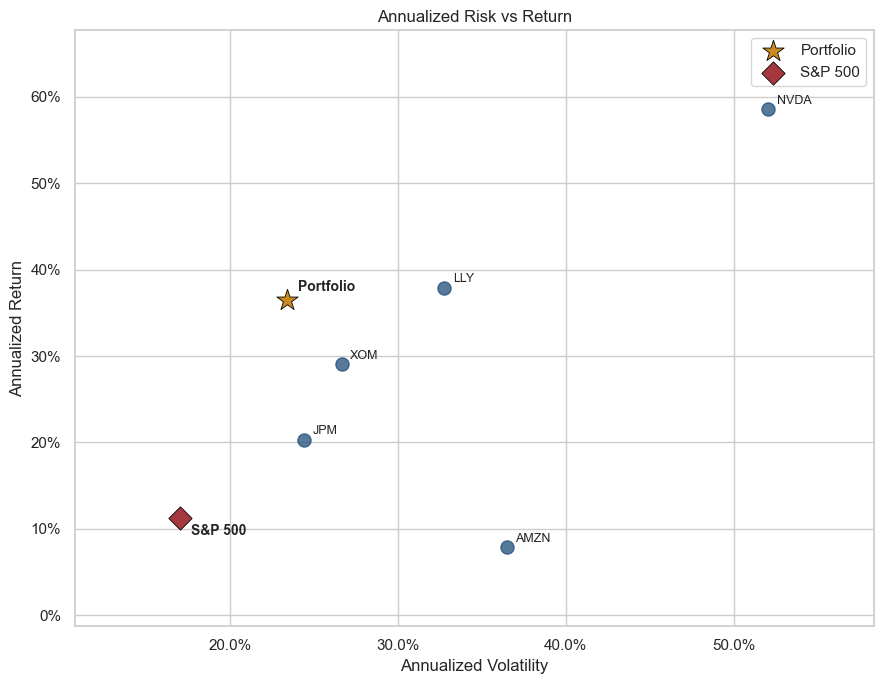

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

for ticker, row in asset_metrics.iterrows():
    ax.scatter(row["Annualized Volatility"], row["Annualized Return"], s=90, color="#1f4e79", alpha=0.75, zorder=3)
    ax.annotate(ticker, (row["Annualized Volatility"], row["Annualized Return"]), textcoords="offset points", xytext=(6, 4), fontsize=9)

portfolio_point = comparison.loc["Portfolio"]
benchmark_point = comparison.loc["S&P 500"]

ax.scatter(portfolio_point["Annualized Volatility"], portfolio_point["Annualized Return"], s=260, marker="*", color="#c98a1f", edgecolor="black", linewidth=0.6, zorder=4, label="Portfolio")
ax.scatter(benchmark_point["Annualized Volatility"], benchmark_point["Annualized Return"], s=140, marker="D", color="#a6373f", edgecolor="black", linewidth=0.6, zorder=4, label="S&P 500")
ax.annotate("Portfolio", (portfolio_point["Annualized Volatility"], portfolio_point["Annualized Return"]), textcoords="offset points", xytext=(8, 6), fontsize=10, fontweight="bold")
ax.annotate("S&P 500", (benchmark_point["Annualized Volatility"], benchmark_point["Annualized Return"]), textcoords="offset points", xytext=(8, -12), fontsize=10, fontweight="bold")

ax.margins(x=0.18, y=0.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.set_title("Annualized Risk vs Return")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

Points further up and to the left represent a more favorable historical risk/return trade-off
- higher annualized return for a given level of volatility. The portfolio marker (star) reflects
the combined effect of diversification across all five holdings, and can sit at a different
risk/return position than any individual stock or the benchmark alone.

## Historical Portfolio Drawdown

Portfolio daily returns and the resulting drawdown series are calculated using the approved
`calculate_portfolio_returns()` and `calculate_portfolio_drawdown()` functions.

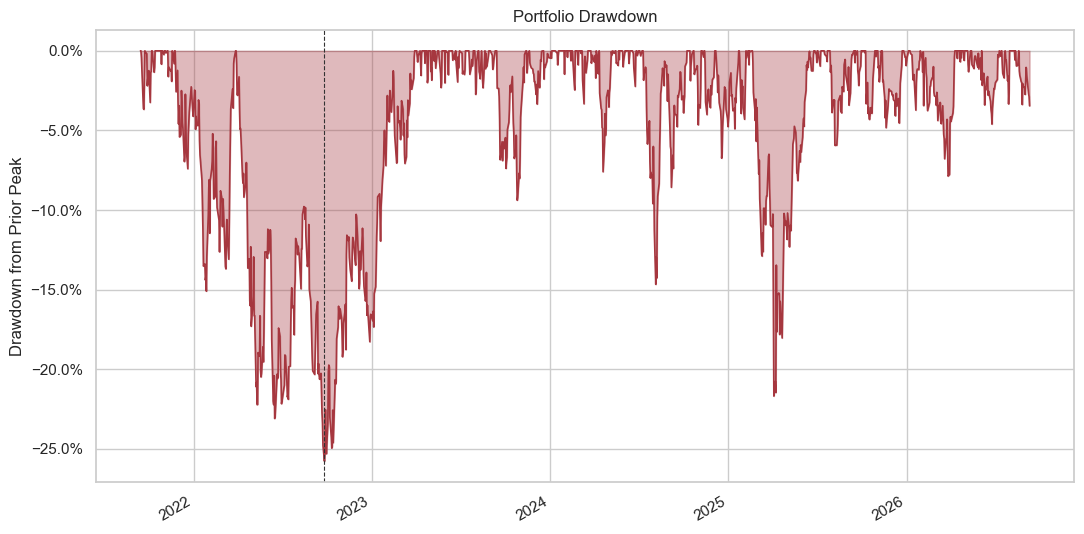

Maximum drawdown: -25.8% on 2022-09-26


In [11]:
portfolio_returns = portfolio.calculate_portfolio_returns(returns, PORTFOLIO_WEIGHTS)
portfolio_drawdown = portfolio.calculate_portfolio_drawdown(portfolio_returns)

max_drawdown_date = portfolio_drawdown.idxmin()
max_drawdown_value = portfolio_drawdown.min()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(portfolio_drawdown.index, portfolio_drawdown, 0, color="#a6373f", alpha=0.35)
ax.plot(portfolio_drawdown.index, portfolio_drawdown, color="#a6373f", linewidth=1.2)
ax.axvline(max_drawdown_date, color="#333333", linestyle="--", linewidth=0.8)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title("Portfolio Drawdown")
ax.set_ylabel("Drawdown from Prior Peak")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"Maximum drawdown: {max_drawdown_value:.1%} on {max_drawdown_date.date()}")

Drawdown measures the percentage decline from a prior peak in cumulative portfolio value at
each point in time. The maximum drawdown is the single largest such decline observed over the
sample period, and is a common way to gauge the depth of historical losses an investor in this
portfolio would have experienced, independent of when in the period they first invested.

## Risk Contribution

`calculate_risk_contribution()` decomposes total annualized portfolio risk into each asset's
weight, marginal risk contribution, and percentage contribution to overall portfolio risk.

In [12]:
risk_contribution = portfolio.calculate_risk_contribution(returns, PORTFOLIO_WEIGHTS)

risk_display = risk_contribution[["Weight", "Risk Contribution %"]].copy()
risk_display["Weight"] = risk_display["Weight"].map(lambda v: f"{v:.1%}")
risk_display["Risk Contribution %"] = risk_display["Risk Contribution %"].map(lambda v: f"{v:.1%}")
risk_display

,Weight,Risk Contribution %
NVDA,25.0%,46.8%
JPM,20.0%,12.4%
AMZN,20.0%,22.9%
LLY,20.0%,12.9%
XOM,15.0%,5.1%


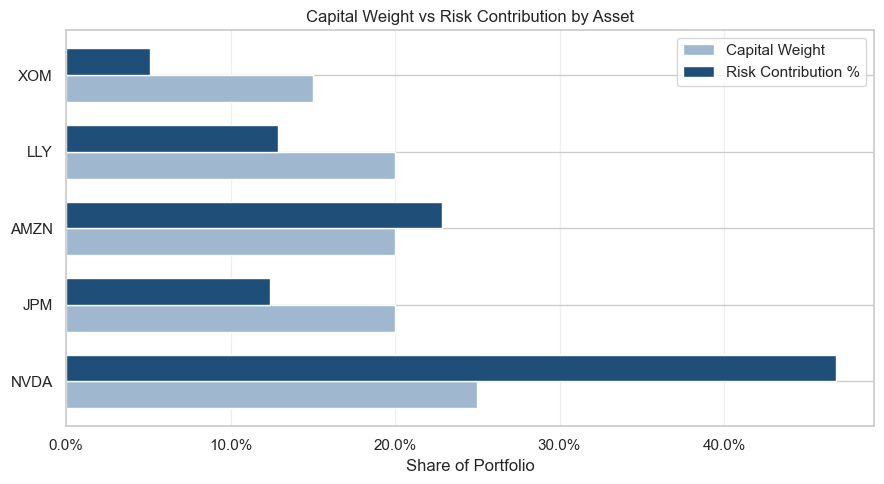

In [13]:
tickers_ordered = risk_contribution.index.tolist()
y_pos = np.arange(len(tickers_ordered))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y_pos - bar_height / 2, risk_contribution["Weight"], height=bar_height, color="#9fb8cf", label="Capital Weight")
ax.barh(y_pos + bar_height / 2, risk_contribution["Risk Contribution %"], height=bar_height, color="#1f4e79", label="Risk Contribution %")

ax.set_yticks(y_pos)
ax.set_yticklabels(tickers_ordered)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_xlabel("Share of Portfolio")
ax.set_title("Capital Weight vs Risk Contribution by Asset")
ax.legend(loc="best")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

## Key Analytical Findings

The summary below is generated programmatically from the results computed above, so it remains
valid if the underlying cached dataset is refreshed.

In [14]:
top_contributor = risk_contribution["Risk Contribution %"].idxmax()
top_contributor_risk_pct = risk_contribution.loc[top_contributor, "Risk Contribution %"]
top_contributor_weight = risk_contribution.loc[top_contributor, "Weight"]

bottom_contributor = risk_contribution["Risk Contribution %"].idxmin()
bottom_contributor_risk_pct = risk_contribution.loc[bottom_contributor, "Risk Contribution %"]
bottom_contributor_weight = risk_contribution.loc[bottom_contributor, "Weight"]

portfolio_row = portfolio_summary.loc["Portfolio"]
outperformance = "outperformed" if portfolio_return > benchmark_return else "underperformed"

findings = f"""\
- The portfolio produced an annualized return of **{portfolio_row['Annualized Return']:.1%}** with \
annualized volatility of **{portfolio_row['Annualized Volatility']:.1%}**, for a Sharpe ratio of \
**{portfolio_row['Sharpe Ratio']:.2f}**.
- The maximum historical portfolio drawdown was **{max_drawdown_value:.1%}** (on {max_drawdown_date.date()}), \
and the portfolio\'s beta versus the S&P 500 was **{portfolio_row['Beta']:.2f}**.
- Over this period, the portfolio **{outperformance}** the S&P 500 on an annualized-return basis.
- **{top_contributor}** contributes the largest share of total portfolio risk, at \
**{top_contributor_risk_pct:.1%}** versus its **{top_contributor_weight:.1%}** capital weight - a case \
where risk concentration exceeds capital allocation.
- **{bottom_contributor}** contributes the smallest share of total portfolio risk, at \
**{bottom_contributor_risk_pct:.1%}** versus its **{bottom_contributor_weight:.1%}** capital weight - a \
case where risk contribution is lower than capital allocation.
- These are historical, descriptive results specific to the current cached dataset and time period. \
They are not investment advice, and past performance is not indicative of future results.
"""

display(Markdown(findings))

- The portfolio produced an annualized return of **36.5%** with annualized volatility of **23.4%**, for a Sharpe ratio of **1.39**.
- The maximum historical portfolio drawdown was **-25.8%** (on 2022-09-26), and the portfolio's beta versus the S&P 500 was **1.20**.
- Over this period, the portfolio **outperformed** the S&P 500 on an annualized-return basis.
- **NVDA** contributes the largest share of total portfolio risk, at **46.8%** versus its **25.0%** capital weight - a case where risk concentration exceeds capital allocation.
- **XOM** contributes the smallest share of total portfolio risk, at **5.1%** versus its **15.0%** capital weight - a case where risk contribution is lower than capital allocation.
- These are historical, descriptive results specific to the current cached dataset and time period. They are not investment advice, and past performance is not indicative of future results.
